# Statistical Testing

This notebook evaluates whether several patterns identified during exploratory analysis are statistically meaningful.

The statistical analysis uses the full cleaned dataset of 4,974 reviews because the tested variables do not require English-language text.

The main questions are:

1. Do recommended and non-recommended reviews differ in playtime?
2. Do recommended and non-recommended reviews differ in review length?
3. Are negative reviews more likely to receive helpful votes?
4. Does recommendation rate differ across months?
5. What is the uncertainty around monthly recommendation rates?

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    mannwhitneyu,
    chi2_contingency,
)

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = (
    project_root
    / "data"
    / "processed"
    / "dst_reviews_cleaned_all.csv"
)

tables_dir = project_root / "outputs" / "tables"
figures_dir = project_root / "outputs" / "figures"

tables_dir.mkdir(
    parents=True,
    exist_ok=True,
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

Dataset shape: (4974, 28)


In [2]:
df["voted_up"] = (
    df["voted_up"]
    .astype(str)
    .str.lower()
    .map({
        "true": True,
        "false": False,
    })
)

df["has_helpful_vote"] = (
    df["votes_up"] > 0
)

positive_df = df[
    df["voted_up"] == True
].copy()

negative_df = df[
    df["voted_up"] == False
].copy()

print("Recommended:", len(positive_df))
print("Not recommended:", len(negative_df))

Recommended: 4512
Not recommended: 462


## 1. Playtime Difference

Playtime has a strongly right-skewed distribution with extreme values. Therefore, a Mann–Whitney U test is used instead of relying on a standard independent-samples t-test.

The null hypothesis is that the distributions of playtime at review are the same for recommended and non-recommended reviews.

In [3]:
positive_playtime = (
    positive_df["playtime_at_review_hours"]
    .dropna()
)

negative_playtime = (
    negative_df["playtime_at_review_hours"]
    .dropna()
)

playtime_test = mannwhitneyu(
    positive_playtime,
    negative_playtime,
    alternative="two-sided",
)

n_positive = len(positive_playtime)
n_negative = len(negative_playtime)

playtime_rank_biserial = (
    2 * playtime_test.statistic
    / (n_positive * n_negative)
    - 1
)

playtime_results = pd.DataFrame({
    "metric": [
        "Recommended n",
        "Not recommended n",
        "Recommended median hours",
        "Not recommended median hours",
        "Median difference hours",
        "Mann-Whitney U",
        "p-value",
        "Rank-biserial correlation",
    ],
    "value": [
        n_positive,
        n_negative,
        positive_playtime.median(),
        negative_playtime.median(),
        (
            positive_playtime.median()
            - negative_playtime.median()
        ),
        playtime_test.statistic,
        playtime_test.pvalue,
        playtime_rank_biserial,
    ],
})

playtime_results

,metric,value
0,Recommended n,4.512000e+03
1,Not recommended n,4.620000e+02
2,Recommended median hours,3.284167e+01
3,Not recommended median hours,7.791667e+00
4,Median difference hours,2.505000e+01
5,Mann-Whitney U,1.456264e+06
6,p-value,4.866319e-45
7,Rank-biserial correlation,3.972010e-01


### Interpretation

Recommended reviews were submitted after a median of 32.84 hours of playtime, compared with 7.79 hours for non-recommended reviews.

The Mann–Whitney U test found a statistically significant difference in playtime distributions between the two recommendation groups (`p < 0.001`).

The rank-biserial correlation was 0.397, indicating a meaningful difference in the direction of higher playtime among recommended reviews.

The observed median difference was approximately 25 hours. However, this relationship should not be interpreted causally. Players who enjoy the game may simply be more likely to continue playing, while dissatisfied players may stop earlier.

## 2. Review Length Difference

Review word count is also strongly right-skewed. A Mann–Whitney U test is therefore used to compare review length between recommendation categories.

In [4]:
positive_words = (
    positive_df["review_word_count"]
    .dropna()
)

negative_words = (
    negative_df["review_word_count"]
    .dropna()
)

word_test = mannwhitneyu(
    positive_words,
    negative_words,
    alternative="two-sided",
)

n_positive_words = len(positive_words)
n_negative_words = len(negative_words)

word_rank_biserial = (
    2 * word_test.statistic
    / (
        n_positive_words
        * n_negative_words
    )
    - 1
)

word_results = pd.DataFrame({
    "metric": [
        "Recommended n",
        "Not recommended n",
        "Recommended median words",
        "Not recommended median words",
        "Median difference words",
        "Mann-Whitney U",
        "p-value",
        "Rank-biserial correlation",
    ],
    "value": [
        n_positive_words,
        n_negative_words,
        positive_words.median(),
        negative_words.median(),
        (
            positive_words.median()
            - negative_words.median()
        ),
        word_test.statistic,
        word_test.pvalue,
        word_rank_biserial,
    ],
})

word_results

,metric,value
0,Recommended n,4.512000e+03
1,Not recommended n,4.620000e+02
2,Recommended median words,6.000000e+00
3,Not recommended median words,1.300000e+01
4,Median difference words,-7.000000e+00
5,Mann-Whitney U,7.728375e+05
6,p-value,3.844860e-20
7,Rank-biserial correlation,-2.585069e-01


### Interpretation

Recommended reviews contained a median of 6 words, while non-recommended reviews contained a median of 13 words.

The Mann–Whitney U test found a statistically significant difference in review-length distributions (`p < 0.001`).

The rank-biserial correlation was -0.259. The negative direction reflects the ordering of the groups in the test and indicates that non-recommended reviews tended to be longer.

The median difference was 7 words, suggesting that negative reviewers generally provided more detailed written feedback.

## 3. Helpful Vote Difference

A chi-square test of independence is used to test whether receiving at least one helpful vote is associated with recommendation category.

The analysis also reports the difference in helpful-vote rates and Cramér's V as an effect-size measure.

In [5]:
helpful_table = pd.crosstab(
    df["voted_up"],
    df["has_helpful_vote"],
)

helpful_table

has_helpful_vote,False,True
voted_up,,
False,284,178
True,3885,627


In [6]:
chi2_helpful, p_helpful, dof_helpful, expected_helpful = (
    chi2_contingency(helpful_table)
)

n_helpful = helpful_table.to_numpy().sum()

cramers_v_helpful = np.sqrt(
    chi2_helpful / n_helpful
)

positive_helpful_rate = (
    positive_df["has_helpful_vote"].mean()
)

negative_helpful_rate = (
    negative_df["has_helpful_vote"].mean()
)

helpful_rate_difference = (
    negative_helpful_rate
    - positive_helpful_rate
)

helpful_results = pd.DataFrame({
    "metric": [
        "Recommended helpful rate",
        "Not recommended helpful rate",
        "Rate difference",
        "Chi-square statistic",
        "Degrees of freedom",
        "p-value",
        "Cramer's V",
    ],
    "value": [
        positive_helpful_rate,
        negative_helpful_rate,
        helpful_rate_difference,
        chi2_helpful,
        dof_helpful,
        p_helpful,
        cramers_v_helpful,
    ],
})

helpful_results

,metric,value
0,Recommended helpful rate,1.389628e-01
1,Not recommended helpful rate,3.852814e-01
2,Rate difference,2.463186e-01
3,Chi-square statistic,1.856377e+02
4,Degrees of freedom,1.000000e+00
5,p-value,2.848248e-42
6,Cramer's V,1.931880e-01


### Interpretation

Approximately 13.90% of recommended reviews received at least one helpful vote, compared with 38.53% of non-recommended reviews.

The difference was approximately 24.63 percentage points.

The chi-square test found a statistically significant association between recommendation status and receiving a helpful vote (`p < 0.001`).

Cramér's V was 0.193, indicating that the association is statistically clear but moderate in practical magnitude.

Negative reviews were therefore substantially more likely to receive at least one helpful vote. However, helpful votes may also depend on review age, visibility, and review length, so recommendation status should not be treated as the sole explanation.

In [7]:
n_pos = len(positive_df)
n_neg = len(negative_df)

p_pos = positive_helpful_rate
p_neg = negative_helpful_rate

difference = p_neg - p_pos

standard_error = np.sqrt(
    p_neg * (1 - p_neg) / n_neg
    +
    p_pos * (1 - p_pos) / n_pos
)

lower_ci = difference - 1.96 * standard_error
upper_ci = difference + 1.96 * standard_error

print(
    "Helpful-vote rate difference:",
    f"{difference * 100:.2f} percentage points",
)

print(
    "95% CI:",
    f"[{lower_ci * 100:.2f}, "
    f"{upper_ci * 100:.2f}] percentage points",
)

Helpful-vote rate difference: 24.63 percentage points
95% CI: [20.08, 29.18] percentage points


## 4. Recommendation Rate Across Months

The first and final months are incomplete collection periods and are excluded from the month-level hypothesis test.

A chi-square test of independence is used to test whether recommendation status is associated with review month.

In [8]:
first_month = df["review_month"].min()
last_month = df["review_month"].max()

complete_month_df = df[
    ~df["review_month"].isin([
        first_month,
        last_month,
    ])
].copy()

monthly_table = pd.crosstab(
    complete_month_df["review_month"],
    complete_month_df["voted_up"],
)

monthly_table

voted_up,False,True
review_month,,
2025-12,49,477
2026-01,46,406
2026-02,46,394
2026-03,37,374
2026-04,49,504
2026-05,45,409
2026-06,90,800
2026-07,86,691


In [9]:
chi2_month, p_month, dof_month, expected_month = (
    chi2_contingency(monthly_table)
)

n_month = monthly_table.to_numpy().sum()

rows, columns = monthly_table.shape

cramers_v_month = np.sqrt(
    chi2_month
    /
    (
        n_month
        * min(
            rows - 1,
            columns - 1,
        )
    )
)

monthly_test_results = pd.DataFrame({
    "metric": [
        "Chi-square statistic",
        "Degrees of freedom",
        "p-value",
        "Cramer's V",
        "Reviews included",
    ],
    "value": [
        chi2_month,
        dof_month,
        p_month,
        cramers_v_month,
        n_month,
    ],
})

monthly_test_results

,metric,value
0,Chi-square statistic,2.642905
1,Degrees of freedom,7.000000
2,p-value,0.915957
3,Cramer's V,0.024226
4,Reviews included,4503.000000


### Interpretation

After excluding the two incomplete months, 4,503 reviews were included in the monthly comparison.

The chi-square test found no statistically significant association between review month and recommendation status (`p = 0.916`).

Cramér's V was only 0.024, indicating a negligible association.

Although monthly recommendation rates showed small visible fluctuations in the exploratory analysis, the statistical test provides no evidence that recommendation behaviour differed meaningfully across the complete months in this dataset.

This illustrates why visual differences should be validated statistically before being interpreted as meaningful changes in user sentiment.

In [10]:
def wilson_interval(
    successes,
    total,
    z=1.96,
):
    proportion = successes / total

    denominator = (
        1
        + z**2 / total
    )

    centre = (
        proportion
        + z**2 / (2 * total)
    )

    adjustment = (
        z
        * np.sqrt(
            proportion
            * (1 - proportion)
            / total
            +
            z**2
            / (4 * total**2)
        )
    )

    lower = (
        centre - adjustment
    ) / denominator

    upper = (
        centre + adjustment
    ) / denominator

    return lower, upper

In [11]:
monthly_ci = (
    df.groupby("review_month")
    .agg(
        total_reviews=(
            "recommendation_id",
            "count",
        ),
        positive_reviews=(
            "voted_up",
            "sum",
        ),
    )
    .reset_index()
)

monthly_ci["positive_rate"] = (
    monthly_ci["positive_reviews"]
    / monthly_ci["total_reviews"]
)

intervals = monthly_ci.apply(
    lambda row: wilson_interval(
        row["positive_reviews"],
        row["total_reviews"],
    ),
    axis=1,
)

monthly_ci["ci_lower"] = [
    interval[0]
    for interval in intervals
]

monthly_ci["ci_upper"] = [
    interval[1]
    for interval in intervals
]

for column in [
    "positive_rate",
    "ci_lower",
    "ci_upper",
]:
    monthly_ci[column] *= 100

monthly_ci.round(2)

,review_month,total_reviews,positive_reviews,positive_rate,ci_lower,ci_upper
0,2025-11,409,403,98.53,96.84,99.33
1,2025-12,526,477,90.68,87.90,92.88
2,2026-01,452,406,89.82,86.69,92.28
3,2026-02,440,394,89.55,86.34,92.07
4,2026-03,411,374,91.00,87.84,93.40
5,2026-04,553,504,91.14,88.48,93.23
6,2026-05,454,409,90.09,86.99,92.51
7,2026-06,890,800,89.89,87.73,91.70
8,2026-07,777,691,88.93,86.53,90.95
9,2026-08,62,54,87.10,76.55,93.31


In [12]:
monthly_ci.to_csv(
    tables_dir
    / "monthly_positive_rate_confidence_intervals.csv",
    index=False,
)

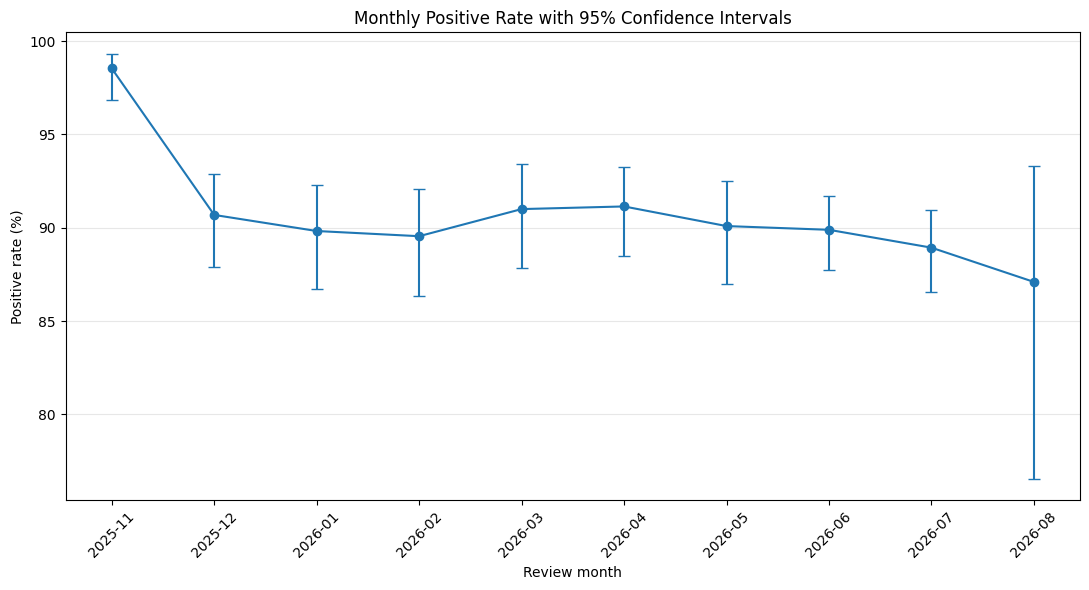

In [13]:
figure, axis = plt.subplots(
    figsize=(11, 6)
)

axis.errorbar(
    monthly_ci["review_month"],
    monthly_ci["positive_rate"],
    yerr=[
        monthly_ci["positive_rate"]
        - monthly_ci["ci_lower"],

        monthly_ci["ci_upper"]
        - monthly_ci["positive_rate"],
    ],
    fmt="o-",
    capsize=4,
)

axis.set_title(
    "Monthly Positive Rate with 95% Confidence Intervals"
)

axis.set_xlabel("Review month")
axis.set_ylabel("Positive rate (%)")

axis.tick_params(
    axis="x",
    rotation=45,
)

axis.grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure.savefig(
    figures_dir
    / "17_monthly_positive_rate_confidence_intervals.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [14]:
statistical_summary = pd.DataFrame({
    "analysis": [
        "Playtime by recommendation",
        "Review length by recommendation",
        "Helpful vote by recommendation",
        "Recommendation rate by month",
    ],

    "test": [
        "Mann-Whitney U",
        "Mann-Whitney U",
        "Chi-square",
        "Chi-square",
    ],

    "statistic": [
        playtime_test.statistic,
        word_test.statistic,
        chi2_helpful,
        chi2_month,
    ],

    "p_value": [
        playtime_test.pvalue,
        word_test.pvalue,
        p_helpful,
        p_month,
    ],

    "effect_size": [
        playtime_rank_biserial,
        word_rank_biserial,
        cramers_v_helpful,
        cramers_v_month,
    ],

    "effect_size_type": [
        "Rank-biserial correlation",
        "Rank-biserial correlation",
        "Cramer's V",
        "Cramer's V",
    ],
})

statistical_summary

,analysis,test,statistic,p_value,effect_size,effect_size_type
0,Playtime by recommendation,Mann-Whitney U,1.456264e+06,4.866319e-45,0.397201,Rank-biserial correlation
1,Review length by recommendation,Mann-Whitney U,7.728375e+05,3.844860e-20,-0.258507,Rank-biserial correlation
2,Helpful vote by recommendation,Chi-square,1.856377e+02,2.848248e-42,0.193188,Cramer's V
3,Recommendation rate by month,Chi-square,2.642905e+00,9.159575e-01,0.024226,Cramer's V


In [15]:
statistical_summary.to_csv(
    tables_dir
    / "statistical_test_summary.csv",
    index=False,
)

In [16]:
statistical_summary_formatted = pd.DataFrame({
    "Analysis": [
        "Playtime by recommendation",
        "Review length by recommendation",
        "Helpful vote by recommendation",
        "Recommendation rate by month",
    ],

    "Test": [
        "Mann–Whitney U",
        "Mann–Whitney U",
        "Chi-square",
        "Chi-square",
    ],

    "Statistic": [
        playtime_test.statistic,
        word_test.statistic,
        chi2_helpful,
        chi2_month,
    ],

    "p-value": [
        playtime_test.pvalue,
        word_test.pvalue,
        p_helpful,
        p_month,
    ],

    "Effect size": [
        playtime_rank_biserial,
        word_rank_biserial,
        cramers_v_helpful,
        cramers_v_month,
    ],

    "Effect size measure": [
        "Rank-biserial correlation",
        "Rank-biserial correlation",
        "Cramer's V",
        "Cramer's V",
    ],
})

statistical_summary_formatted["Statistic"] = (
    statistical_summary_formatted["Statistic"]
    .round(3)
)

statistical_summary_formatted["Effect size"] = (
    statistical_summary_formatted["Effect size"]
    .round(3)
)

statistical_summary_formatted["p-value formatted"] = (
    statistical_summary_formatted["p-value"]
    .apply(
        lambda value:
        "< 0.001"
        if value < 0.001
        else f"{value:.3f}"
    )
)

statistical_summary_formatted[
    [
        "Analysis",
        "Test",
        "Statistic",
        "p-value formatted",
        "Effect size",
        "Effect size measure",
    ]
]

,Analysis,Test,Statistic,p-value formatted,Effect size,Effect size measure
0,Playtime by recommendation,Mann–Whitney U,1456263.500,< 0.001,0.397,Rank-biserial correlation
1,Review length by recommendation,Mann–Whitney U,772837.500,< 0.001,-0.259,Rank-biserial correlation
2,Helpful vote by recommendation,Chi-square,185.638,< 0.001,0.193,Cramer's V
3,Recommendation rate by month,Chi-square,2.643,0.916,0.024,Cramer's V


## Statistical Analysis Summary

The statistical tests provided additional evidence for several patterns identified during exploratory analysis.

### Main findings

1. **Playtime differed substantially by recommendation status.**  
   Recommended reviews had a median playtime of 32.84 hours compared with 7.79 hours for non-recommended reviews. The difference was statistically significant and had a meaningful effect size.

2. **Negative reviews tended to be longer.**  
   Non-recommended reviews contained a median of 13 words compared with 6 words for recommended reviews. The difference was statistically significant, although the effect size was smaller than for playtime.

3. **Negative reviews were more likely to receive helpful votes.**  
   38.53% of non-recommended reviews received at least one helpful vote compared with 13.90% of recommended reviews. The association was statistically significant.

4. **Monthly recommendation rates did not differ significantly.**  
   After excluding incomplete months, the chi-square test found no meaningful association between review month and recommendation status. Small month-to-month fluctuations observed in the exploratory analysis should therefore not be interpreted as evidence of a systematic sentiment change.

### Business interpretation

The strongest practical pattern is associated with the early player experience. Negative reviews were submitted much earlier in the player lifecycle and were generally more detailed and more likely to receive helpful votes.

These findings suggest that early-player feedback may deserve particular attention when prioritising review analysis. However, the observational nature of the dataset means that these relationships should not be interpreted as causal effects.

In [17]:
statistical_summary.to_csv(
    tables_dir / "statistical_test_summary.csv",
    index=False,
)

In [18]:
monthly_ci.to_csv(
    tables_dir
    / "monthly_positive_rate_confidence_intervals.csv",
    index=False,
)